# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [7]:
%pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [12]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

## Notebook Presentation

In [15]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [18]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [21]:
print(df_hh_income.shape)
print(df_pct_poverty.shape)
print(df_pct_completed_hs.shape)
print(df_share_race_city.shape)
print(df_fatalities.shape)

(29322, 3)
(29329, 3)
(29329, 3)
(29268, 7)
(2535, 14)


In [23]:
print(df_hh_income.columns) 
print(df_pct_poverty.columns) 
print(df_pct_completed_hs.columns) 
print(df_share_race_city.columns) 
print(df_fatalities.columns) 

Index(['Geographic Area', 'City', 'Median Income'], dtype='object')
Index(['Geographic Area', 'City', 'poverty_rate'], dtype='object')
Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='object')
Index(['Geographic area', 'City', 'share_white', 'share_black',
       'share_native_american', 'share_asian', 'share_hispanic'],
      dtype='object')
Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
       'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level',
       'flee', 'body_camera'],
      dtype='object')


In [29]:
print("Median Household Income")
print(df_hh_income.isna().sum(), "\n")

print("Poverty")
print(df_pct_poverty.isna().sum(), "\n")

print("High School Completion")
print(df_pct_completed_hs.isna().sum(), "\n")

print("Race Share")
print(df_share_race_city.isna().sum(), "\n")

print("Fatalities")
print(df_fatalities.isna().sum())

Median Household Income
Geographic Area     0
City                0
Median Income      51
dtype: int64 

Poverty
Geographic Area    0
City               0
poverty_rate       0
dtype: int64 

High School Completion
Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64 

Race Share
Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64 

Fatalities
id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [31]:
print("Household Income:", df_hh_income.duplicated().sum())
print("Poverty:", df_pct_poverty.duplicated().sum())
print("High School:", df_pct_completed_hs.duplicated().sum())
print("Race Share:", df_share_race_city.duplicated().sum())
print("Fatalities:", df_fatalities.duplicated().sum())

Household Income: 0
Poverty: 0
High School: 0
Race Share: 0
Fatalities: 0


In [33]:
df_hh_income.fillna(0, inplace=True)
df_pct_poverty.fillna(0, inplace=True)
df_pct_completed_hs.fillna(0, inplace=True)
df_share_race_city.fillna(0, inplace=True)
df_fatalities.fillna(0, inplace=True)

# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [37]:
df_pct_poverty["poverty_rate"] = pd.to_numeric(
    df_pct_poverty["poverty_rate"],
    errors="coerce"
)

df_pct_poverty["poverty_rate"] = df_pct_poverty["poverty_rate"].fillna(0)

In [39]:
poverty_by_state = (
    df_pct_poverty
    .groupby("Geographic Area")["poverty_rate"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

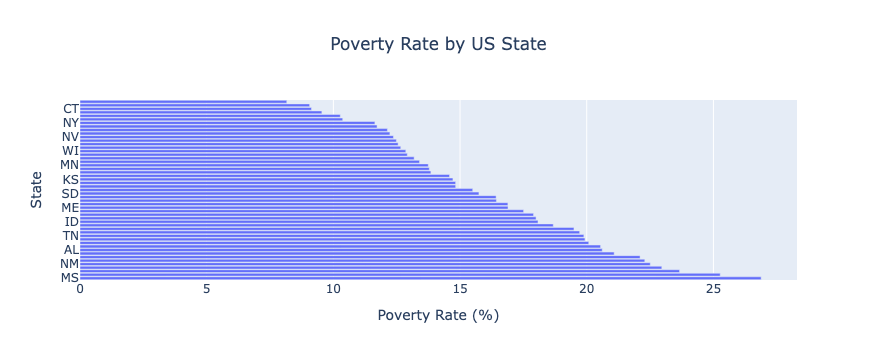

In [41]:
import plotly.express as px

# Average poverty rate by state
poverty_by_state = (
    df_pct_poverty
    .groupby("Geographic Area")["poverty_rate"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Horizontal bar chart
fig = px.bar(
    poverty_by_state,
    x="poverty_rate",
    y="Geographic Area",
    orientation="h",
    title="Poverty Rate by US State",
    labels={
        "Geographic Area": "State",
        "poverty_rate": "Poverty Rate (%)"
    }
)

fig.update_layout(title_x=0.5)

fig.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [43]:
df_pct_completed_hs["percent_completed_hs"] = pd.to_numeric(
    df_pct_completed_hs["percent_completed_hs"],
    errors="coerce"
)

df_pct_completed_hs["percent_completed_hs"] = df_pct_completed_hs["percent_completed_hs"].fillna(0)

In [45]:
hs_by_state = (
    df_pct_completed_hs
    .groupby("Geographic Area")["percent_completed_hs"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)

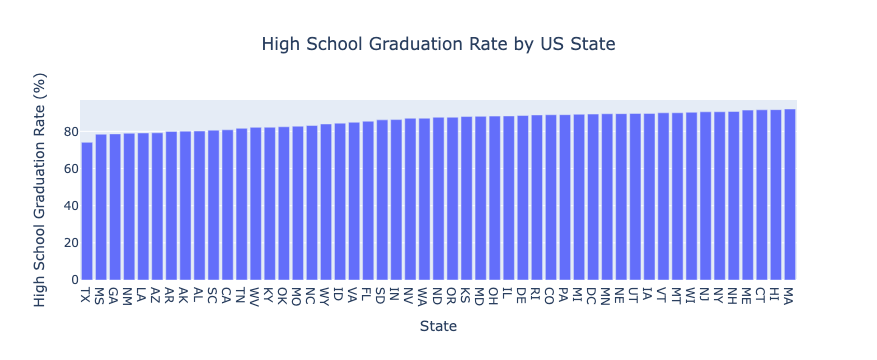

In [47]:
import plotly.express as px

fig = px.bar(
    hs_by_state,
    x="Geographic Area",
    y="percent_completed_hs",
    title="High School Graduation Rate by US State",
    labels={
        "Geographic Area": "State",
        "percent_completed_hs": "High School Graduation Rate (%)"
    }
)

fig.update_layout(title_x=0.5)

fig.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [49]:
merged_df = pd.merge(
    poverty_by_state,
    hs_by_state,
    on="Geographic Area"
)

merged_df.head()

,Geographic Area,poverty_rate,percent_completed_hs
0,MS,26.88,78.47
1,AZ,25.27,79.22
2,GA,23.66,78.63
3,AR,22.96,79.95
4,NM,22.51,78.97


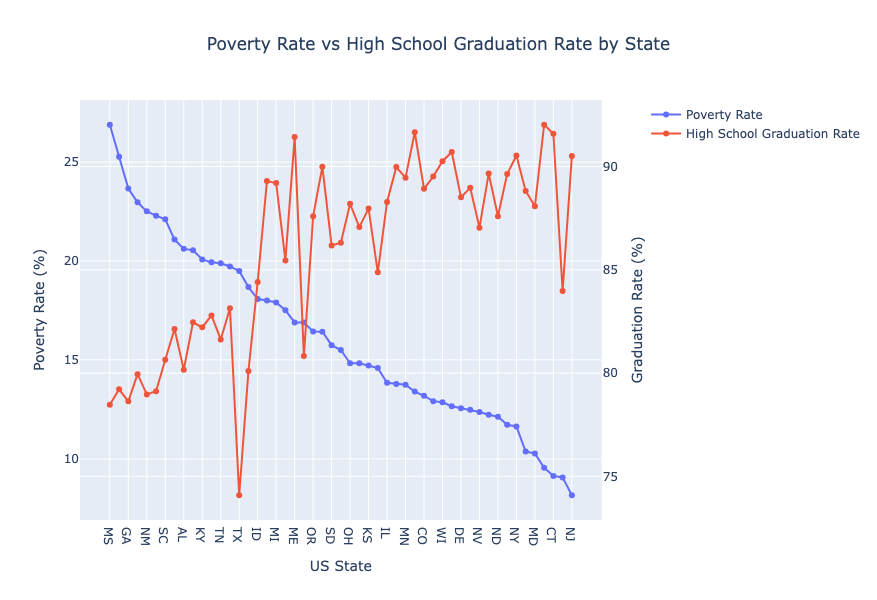

In [51]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Poverty Rate
fig.add_trace(
    go.Scatter(
        x=merged_df["Geographic Area"],
        y=merged_df["poverty_rate"],
        name="Poverty Rate",
        mode="lines+markers"
    ),
    secondary_y=False
)

# High School Graduation Rate
fig.add_trace(
    go.Scatter(
        x=merged_df["Geographic Area"],
        y=merged_df["percent_completed_hs"],
        name="High School Graduation Rate",
        mode="lines+markers"
    ),
    secondary_y=True
)

fig.update_layout(
    title="Poverty Rate vs High School Graduation Rate by State",
    xaxis_title="US State",
    title_x=0.5,
    width=1200,
    height=600
)

fig.update_yaxes(title_text="Poverty Rate (%)", secondary_y=False)
fig.update_yaxes(title_text="Graduation Rate (%)", secondary_y=True)

fig.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

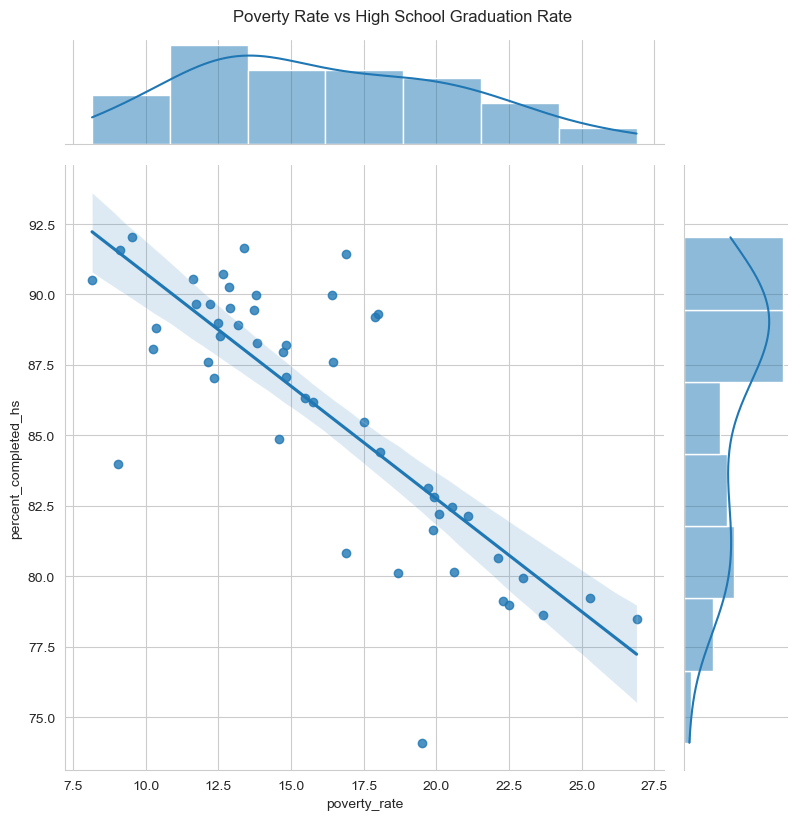

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

sns.jointplot(
    data=merged_df,
    x="poverty_rate",
    y="percent_completed_hs",
    kind="reg",
    height=8
)

plt.suptitle("Poverty Rate vs High School Graduation Rate", y=1.02)
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

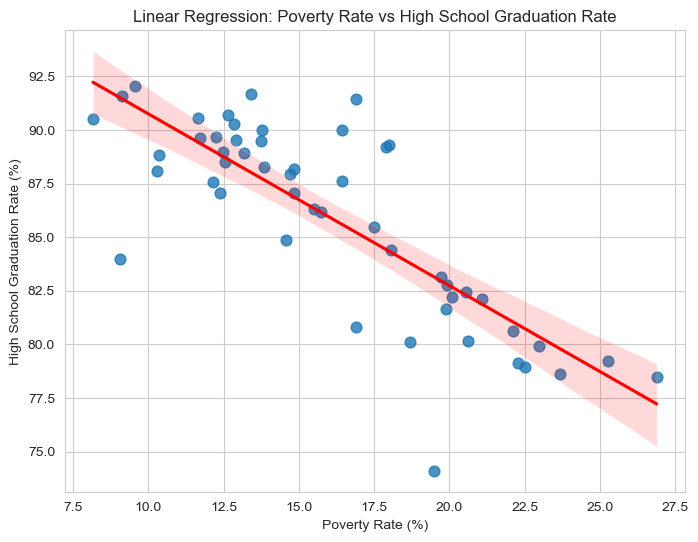

In [59]:
# Regplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.regplot(
    data=merged_df,
    x="poverty_rate",
    y="percent_completed_hs",
    scatter_kws={"s":60},
    line_kws={"color":"red"}
)

plt.title("Linear Regression: Poverty Rate vs High School Graduation Rate")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("High School Graduation Rate (%)")

plt.show()

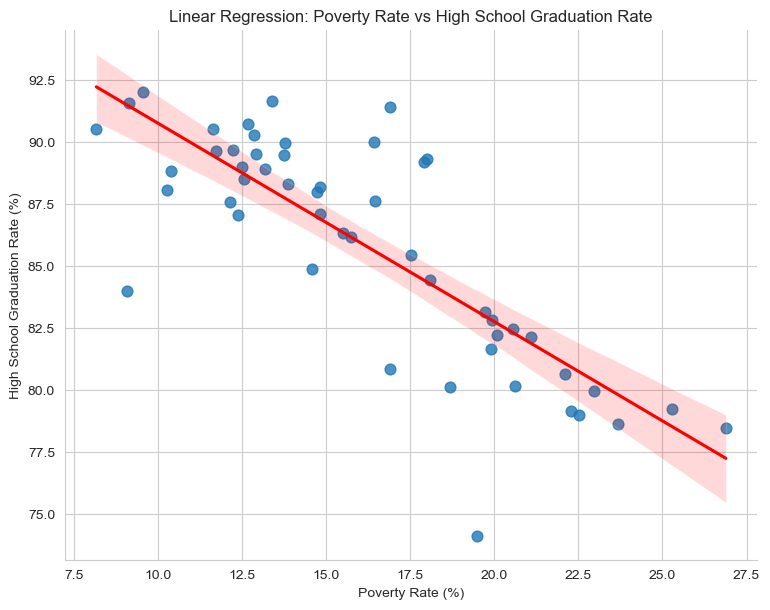

In [61]:
# Lmplot
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(
    data=merged_df,
    x="poverty_rate",
    y="percent_completed_hs",
    height=6,
    aspect=1.3,
    scatter_kws={"s":60},
    line_kws={"color":"red"}
)

plt.title("Linear Regression: Poverty Rate vs High School Graduation Rate")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("High School Graduation Rate (%)")

plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [63]:
race_cols = ["share_white", "share_black", "share_hispanic",
             "share_asian", "share_native_american"]

for col in race_cols:
    df_share_race_city[col] = pd.to_numeric(
        df_share_race_city[col],
        errors="coerce"
    )

df_share_race_city[race_cols] = df_share_race_city[race_cols].fillna(0)

In [65]:
race_by_state = (
    df_share_race_city
    .groupby("Geographic area")[race_cols]
    .mean()
    .reset_index()
)

race_by_state.head()

,Geographic area,share_white,share_black,share_hispanic,share_asian,share_native_american
0,AK,45.26,0.56,2.13,1.38,45.48
1,AL,72.51,23.32,2.98,0.48,0.66
2,AR,78.45,16.30,4.27,0.48,0.76
3,AZ,59.93,0.95,20.14,0.73,28.59
4,CA,71.54,2.68,29.51,5.54,1.72


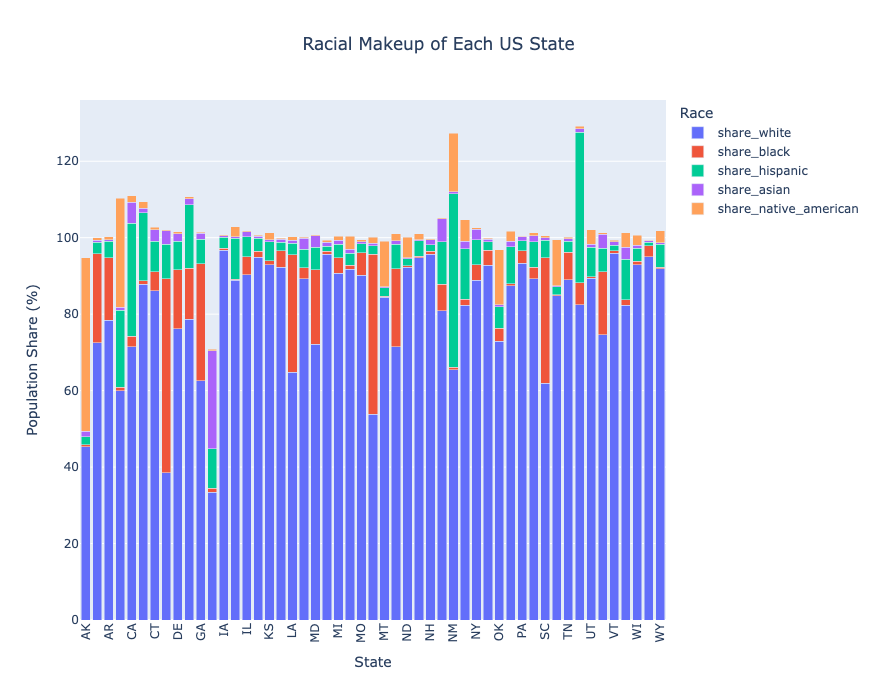

In [67]:
import plotly.express as px

fig = px.bar(
    race_by_state,
    x="Geographic area",
    y=race_cols,
    title="Racial Makeup of Each US State",
    labels={
        "value": "Population Share (%)",
        "variable": "Race",
        "Geographic area": "State"
    }
)

fig.update_layout(
    barmode="stack",
    title_x=0.5,
    xaxis_tickangle=-90,
    width=1400,
    height=700
)

fig.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [69]:
race_count = df_fatalities["race"].value_counts()

race_count

race
W    1201
B     618
H     423
0     195
A      39
N      31
O      28
Name: count, dtype: int64

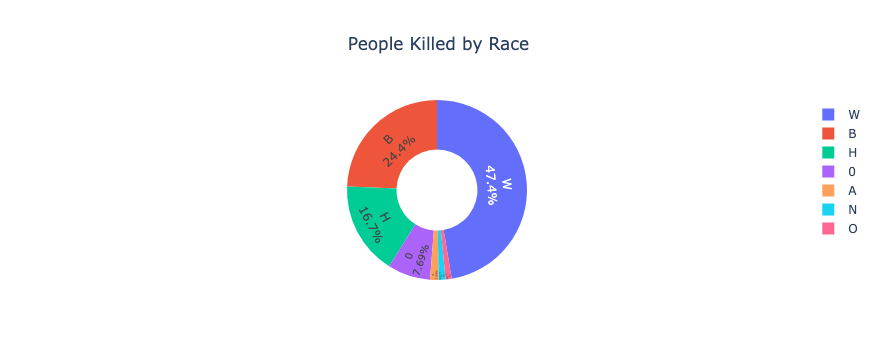

In [71]:
import plotly.express as px

fig = px.pie(
    values=race_count.values,
    names=race_count.index,
    title="People Killed by Race"
)

# Make it a donut chart
fig.update_traces(
    hole=0.45,
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(title_x=0.5)

fig.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

In [73]:
import plotly.express as px

# Count deaths by gender
gender_count = df_fatalities["gender"].value_counts()

gender_count

gender
M    2428
F     107
Name: count, dtype: int64

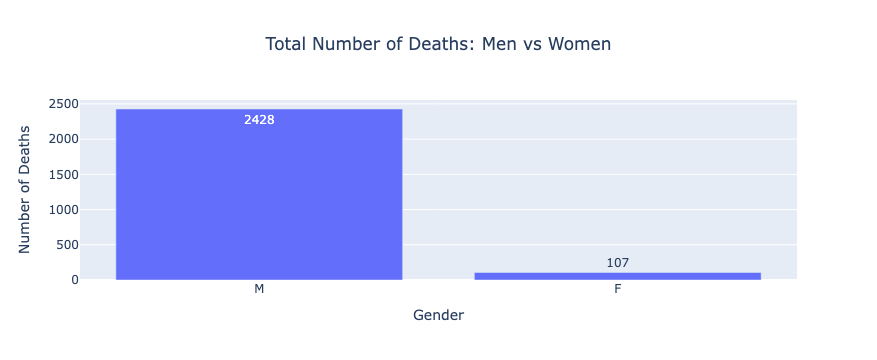

In [75]:
fig = px.bar(
    x=gender_count.index,
    y=gender_count.values,
    labels={
        "x": "Gender",
        "y": "Number of Deaths"
    },
    title="Total Number of Deaths: Men vs Women",
    text=gender_count.values
)

fig.update_layout(title_x=0.5)

fig.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

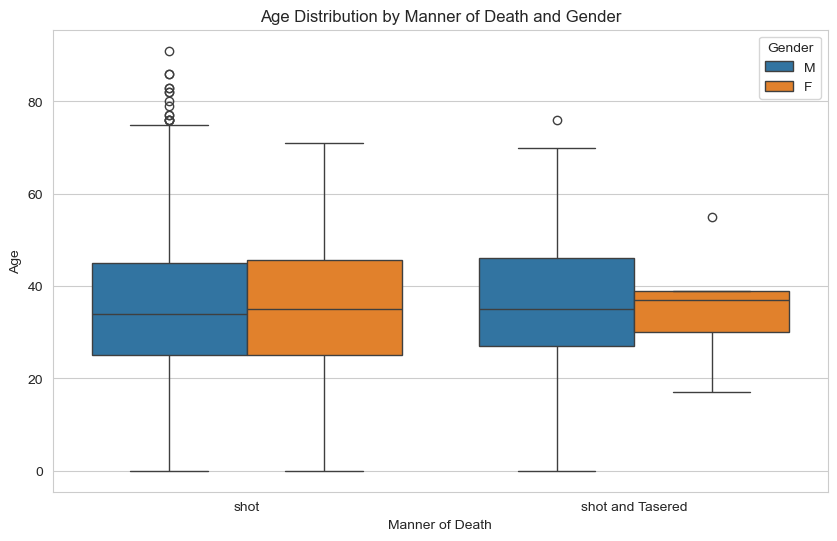

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert age to numeric (if required)
df_fatalities["age"] = pd.to_numeric(df_fatalities["age"], errors="coerce")

# Remove missing values
box_df = df_fatalities.dropna(subset=["age", "manner_of_death", "gender"])

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=box_df,
    x="manner_of_death",
    y="age",
    hue="gender"
)

plt.title("Age Distribution by Manner of Death and Gender")
plt.xlabel("Manner of Death")
plt.ylabel("Age")
plt.legend(title="Gender")

plt.show()

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

In [79]:
# Count armed status
armed_count = df_fatalities["armed"].value_counts()

# Percentage
armed_percentage = (
    df_fatalities["armed"].notna().sum() / len(df_fatalities)
) * 100

print(f"Percentage of people who were armed: {armed_percentage:.2f}%")

Percentage of people who were armed: 100.00%


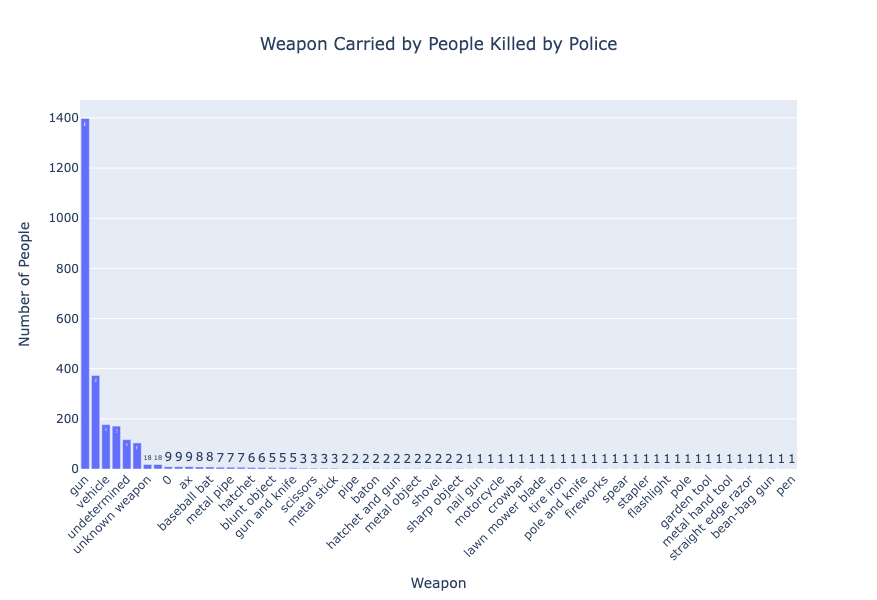

In [81]:
import plotly.express as px

weapon_count = df_fatalities["armed"].value_counts()

fig = px.bar(
    x=weapon_count.index,
    y=weapon_count.values,
    labels={
        "x": "Weapon",
        "y": "Number of People"
    },
    title="Weapon Carried by People Killed by Police",
    text=weapon_count.values
)

fig.update_layout(
    title_x=0.5,
    xaxis_tickangle=-45,
    width=1000,
    height=600
)

fig.show()

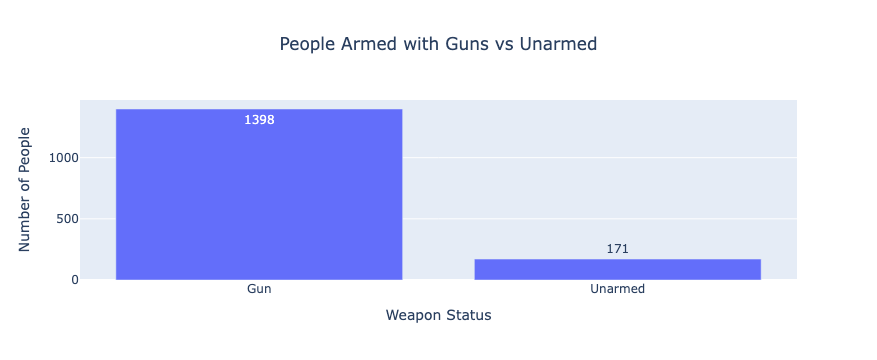

Armed with Gun : 1398
Unarmed        : 171


In [83]:
gun_count = (df_fatalities["armed"] == "gun").sum()
unarmed_count = (df_fatalities["armed"] == "unarmed").sum()

comparison = {
    "Gun": gun_count,
    "Unarmed": unarmed_count
}

fig = px.bar(
    x=list(comparison.keys()),
    y=list(comparison.values()),
    text=list(comparison.values()),
    labels={
        "x": "Weapon Status",
        "y": "Number of People"
    },
    title="People Armed with Guns vs Unarmed"
)

fig.update_layout(title_x=0.5)

fig.show()

print(f"Armed with Gun : {gun_count}")
print(f"Unarmed        : {unarmed_count}")

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [85]:
# Convert age to numeric
df_fatalities["age"] = pd.to_numeric(df_fatalities["age"], errors="coerce")

# Remove missing ages
age_df = df_fatalities.dropna(subset=["age"])

# Calculate percentage
under_25 = (age_df["age"] < 25).sum()
total = len(age_df)

percentage = (under_25 / total) * 100

print(f"People under 25 years old: {under_25}")
print(f"Percentage: {percentage:.2f}%")

People under 25 years old: 527
Percentage: 20.79%


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

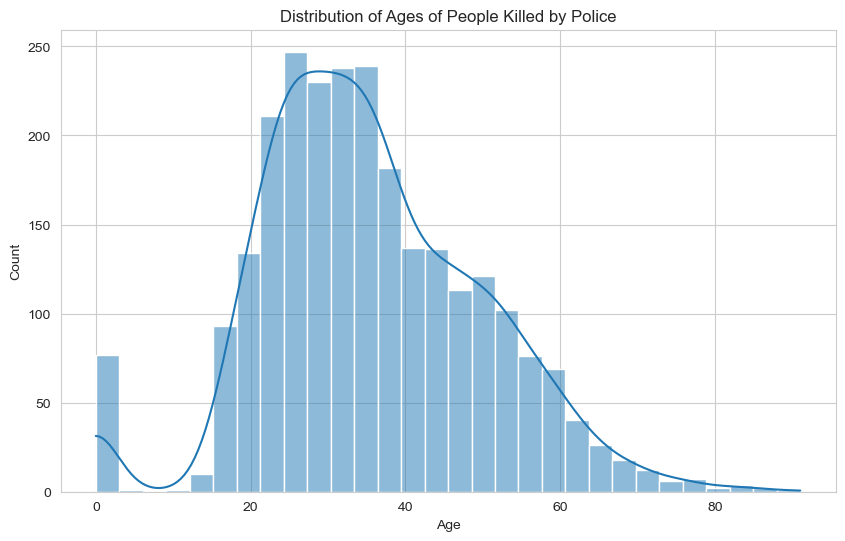

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.histplot(
    data=age_df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Distribution of Ages of People Killed by Police")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

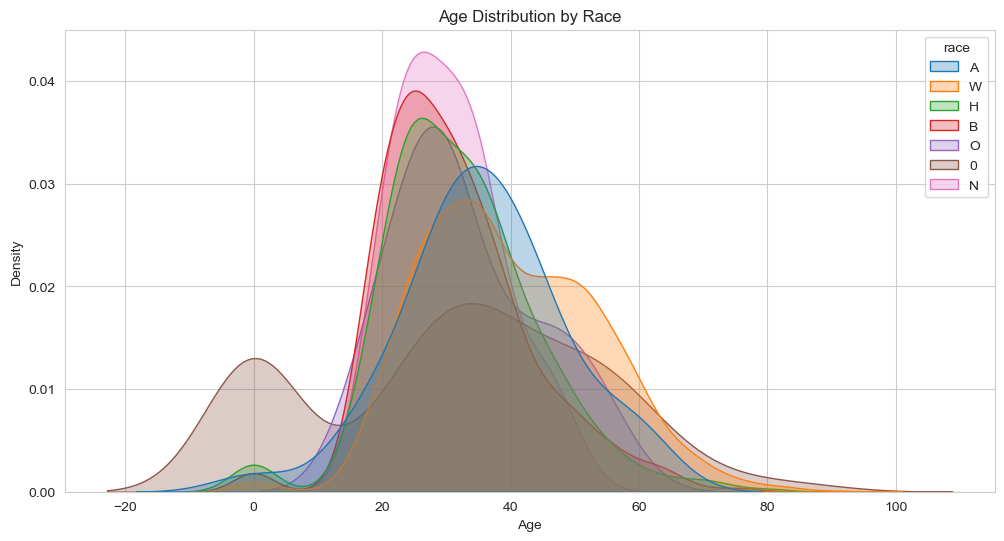

In [89]:
plt.figure(figsize=(12,6))

sns.kdeplot(
    data=age_df,
    x="age",
    hue="race",
    fill=True,
    common_norm=False,
    alpha=0.3
)

plt.title("Age Distribution by Race")
plt.xlabel("Age")
plt.ylabel("Density")

plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

In [93]:
race_count = df_fatalities["race"].value_counts()

race_count

race
W    1201
B     618
H     423
0     195
A      39
N      31
O      28
Name: count, dtype: int64

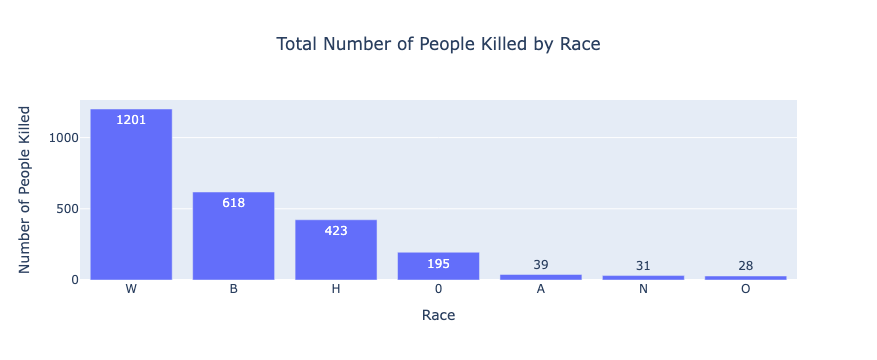

In [95]:
import plotly.express as px

fig = px.bar(
    x=race_count.index,
    y=race_count.values,
    text=race_count.values,
    labels={
        "x": "Race",
        "y": "Number of People Killed"
    },
    title="Total Number of People Killed by Race"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Race",
    yaxis_title="Number of People Killed"
)

fig.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [97]:
# Count people with signs of mental illness
mental_illness_count = df_fatalities["signs_of_mental_illness"].sum()

# Total number of people
total_people = len(df_fatalities)

# Calculate percentage
mental_illness_percentage = (mental_illness_count / total_people) * 100

print(f"People with signs of mental illness: {mental_illness_count}")
print(f"Percentage: {mental_illness_percentage:.2f}%")

People with signs of mental illness: 633
Percentage: 24.97%


# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [99]:
top_10_cities = (
    df_fatalities["city"]
    .value_counts()
    .head(10)
)

top_10_cities

city
Los Angeles    39
Phoenix        31
Houston        27
Chicago        25
Las Vegas      21
San Antonio    20
Columbus       19
Austin         18
Miami          18
St. Louis      15
Name: count, dtype: int64

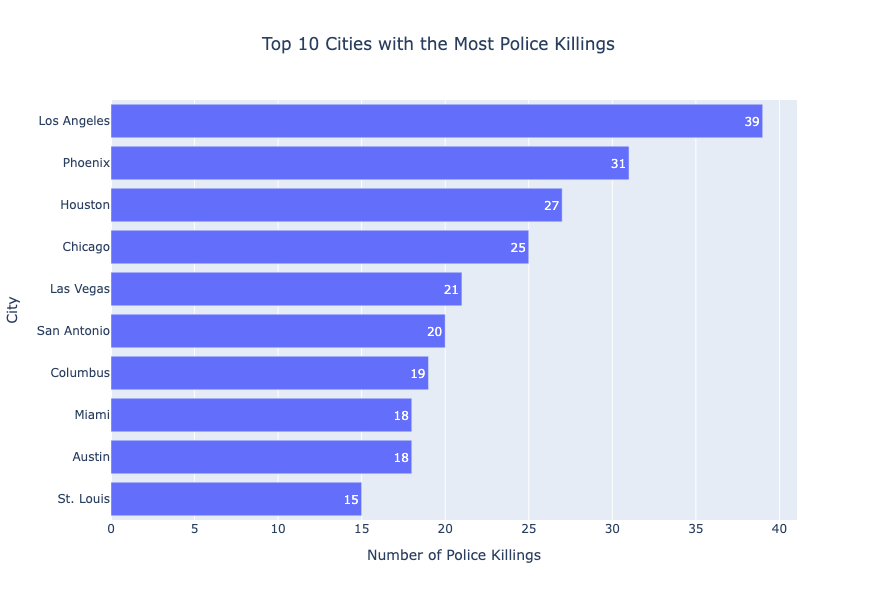

In [101]:
import plotly.express as px

fig = px.bar(
    x=top_10_cities.values,
    y=top_10_cities.index,
    orientation="h",
    text=top_10_cities.values,
    labels={
        "x": "Number of Police Killings",
        "y": "City"
    },
    title="Top 10 Cities with the Most Police Killings"
)

fig.update_layout(
    title_x=0.5,
    yaxis={"categoryorder": "total ascending"},
    width=900,
    height=600
)

fig.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

In [103]:
top_10_cities = (
    df_fatalities["city"]
    .value_counts()
    .head(10)
    .index
)

top_10_cities

Index(['Los Angeles', 'Phoenix', 'Houston', 'Chicago', 'Las Vegas',
       'San Antonio', 'Columbus', 'Austin', 'Miami', 'St. Louis'],
      dtype='object', name='city')

In [115]:
df_share_race_city["City"] = (
    df_share_race_city["City"]
    .str.replace(" city", "", regex=False)
    .str.replace(" town", "", regex=False)
    .str.replace(" village", "", regex=False)
    .str.replace(" CDP", "", regex=False)
    .str.strip()
)

In [117]:
race_columns = [
    "share_white",
    "share_black",
    "share_hispanic",
    "share_asian",
    "share_native_american"
]

city_race = (
    df_share_race_city
    .groupby("City")[race_columns]
    .mean()
)

city_race_top10 = city_race.loc[top_10_cities]

city_race_top10

,share_white,share_black,share_hispanic,share_asian,share_native_american
city,,,,,
Los Angeles,56.70,9.35,74.25,5.65,0.35
Phoenix,62.12,24.88,15.95,1.30,1.20
Houston,81.47,10.14,8.56,1.21,1.29
Chicago,45.00,32.90,28.90,5.50,0.50
Las Vegas,63.50,6.50,56.00,3.50,1.40
San Antonio,88.30,2.67,41.50,1.13,0.50
Columbus,80.00,11.16,10.80,1.36,0.71
Austin,88.44,2.68,13.26,1.96,0.46
Miami,81.40,4.32,28.08,0.38,4.04


In [119]:
fatalities_top10 = df_fatalities[
    df_fatalities["city"].isin(top_10_cities)
]

killings_by_race = (
    fatalities_top10
    .groupby(["city", "race"])
    .size()
    .unstack(fill_value=0)
)

killings_by_race

race,0,A,B,H,N,O,W
city,,,,,,,
Austin,0,0,3,2,0,0,13
Chicago,1,0,21,1,0,0,2
Columbus,1,0,11,0,0,1,6
Houston,1,1,15,6,1,0,3
Las Vegas,4,0,3,5,0,0,9
Los Angeles,3,1,10,19,0,0,6
Miami,1,0,8,6,0,0,3
Phoenix,3,0,2,11,3,0,12
San Antonio,2,0,3,12,0,0,3


In [121]:
comparison = city_race_top10.join(killings_by_race)

comparison

,share_white,share_black,share_hispanic,share_asian,share_native_american,0,A,B,H,N,O,W
city,,,,,,,,,,,,
Los Angeles,56.70,9.35,74.25,5.65,0.35,3,1,10,19,0,0,6
Phoenix,62.12,24.88,15.95,1.30,1.20,3,0,2,11,3,0,12
Houston,81.47,10.14,8.56,1.21,1.29,1,1,15,6,1,0,3
Chicago,45.00,32.90,28.90,5.50,0.50,1,0,21,1,0,0,2
Las Vegas,63.50,6.50,56.00,3.50,1.40,4,0,3,5,0,0,9
San Antonio,88.30,2.67,41.50,1.13,0.50,2,0,3,12,0,0,3
Columbus,80.00,11.16,10.80,1.36,0.71,1,0,11,0,0,1,6
Austin,88.44,2.68,13.26,1.96,0.46,0,0,3,2,0,0,13
Miami,81.40,4.32,28.08,0.38,4.04,1,0,8,6,0,0,3


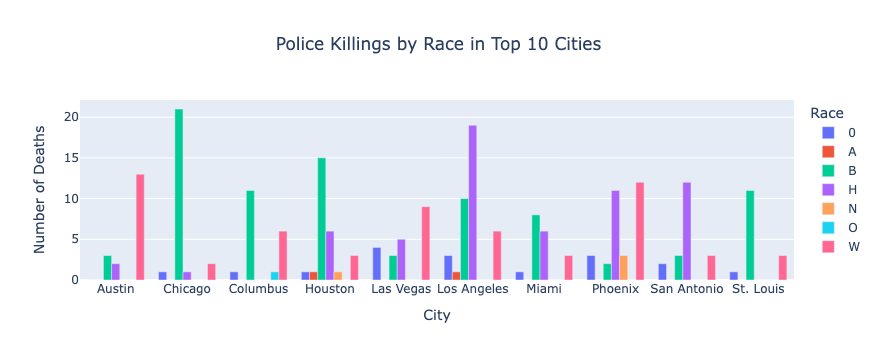

In [123]:
import plotly.express as px

killings_long = (
    killings_by_race
    .reset_index()
    .melt(
        id_vars="city",
        var_name="Race",
        value_name="Deaths"
    )
)

fig = px.bar(
    killings_long,
    x="city",
    y="Deaths",
    color="Race",
    barmode="group",
    title="Police Killings by Race in Top 10 Cities"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="City",
    yaxis_title="Number of Deaths"
)

fig.show()

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [125]:
state_killings = (
    df_fatalities["state"]
    .value_counts()
    .reset_index()
)

state_killings.columns = ["State", "Deaths"]

state_killings

,State,Deaths
0,CA,424
1,TX,225
2,FL,154
3,AZ,118
4,OH,79
5,OK,78
6,CO,74
7,GA,70
8,NC,69
9,MO,64


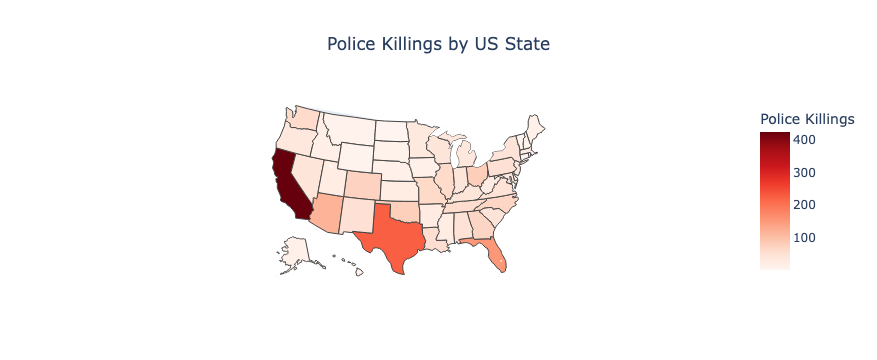

In [127]:
import plotly.express as px

fig = px.choropleth(
    state_killings,
    locations="State",
    locationmode="USA-states",
    color="Deaths",
    scope="usa",
    color_continuous_scale="Reds",
    labels={"Deaths": "Police Killings"},
    title="Police Killings by US State"
)

fig.update_layout(title_x=0.5)

fig.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

In [129]:
df_fatalities["date"] = pd.to_datetime(df_fatalities["date"])

/var/folders/67/_6_dylh17cb7vcnr8wlnl7q80000gn/T/ipykernel_58556/4212182395.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_fatalities["date"] = pd.to_datetime(df_fatalities["date"])


In [131]:
killings_over_time = (
    df_fatalities
    .groupby(pd.Grouper(key="date", freq="M"))
    .size()
    .reset_index(name="Deaths")
)

killings_over_time

/var/folders/67/_6_dylh17cb7vcnr8wlnl7q80000gn/T/ipykernel_58556/3075744352.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(key="date", freq="M"))


,date,Deaths
0,2015-01-31,70
1,2015-02-28,78
2,2015-03-31,87
3,2015-04-30,88
4,2015-05-31,85
5,2015-06-30,68
6,2015-07-31,85
7,2015-08-31,86
8,2015-09-30,90
9,2015-10-31,89


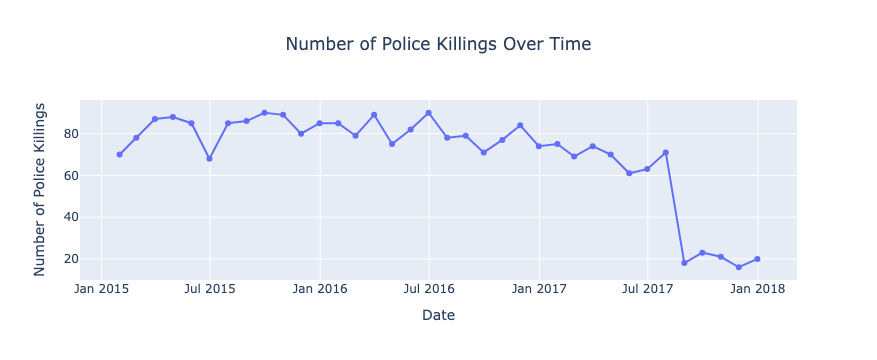

In [133]:
import plotly.express as px

fig = px.line(
    killings_over_time,
    x="date",
    y="Deaths",
    markers=True,
    title="Number of Police Killings Over Time"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Date",
    yaxis_title="Number of Police Killings"
)

fig.show()